# 🏏 IPL Data Analysis (2008–2025)
## Exploratory Data Analysis using Statistical Methods
**Course:** 22IS610 – Statistical Methods in Information Processing  
**Team:** [Add your team names here]  
**Dataset:** IPL Ball-by-Ball Data (2008–2025) | 2,83,678 rows × 65 columns

---
##  Step 0: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway, mannwhitneyu
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')


In [2]:
# Load dataset — make sure IPL.csv is in the same folder as this notebook
df = pd.read_csv('../data/IPL.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (283678, 65)
Columns: ['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'power_surge_start', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False


---
## 🧹 Step 1: Data Preprocessing & Overview

In [3]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Columns with missing values:')
print(missing_df[missing_df['Missing Count'] > 0].to_string())

Columns with missing values:
                   Missing Count  Missing %
extra_type                268185      94.54
wicket_kind               269572      95.03
player_out                269572      95.03
fielders                  273433      96.39
runs_target               147168      51.88
review_batter             282771      99.68
team_reviewed             282771      99.68
review_decision           282771      99.68
umpire                    282771      99.68
win_outcome                 4724       1.67
superover_winner          279782      98.63
result_type               278954      98.33
method                    279788      98.63
new_batter                270085      95.21
power_surge_start         283678     100.00
next_batter               270085      95.21


In [4]:
# Basic info
print(f'Total deliveries: {len(df):,}')
print(f'Unique matches: {df["match_id"].nunique()}')
print(f'Seasons covered: {sorted(df["season"].astype(str).unique())}')
print(f'Unique teams: {df["batting_team"].nunique()}')
print(f'Unique players (batters): {df["batter"].nunique()}')
print(f'Unique venues: {df["venue"].nunique()}')

Total deliveries: 283,678
Unique matches: 1193
Seasons covered: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025', '2026']
Unique teams: 19
Unique players (batters): 719
Unique venues: 59


In [5]:
# Create match-level summary (used across all units)
match_df = df.groupby(['match_id', 'date', 'season', 'year', 'batting_team',
                        'bowling_team', 'venue', 'city', 'toss_winner',
                        'toss_decision', 'match_won_by', 'innings']).agg(
    total_runs=('runs_total', 'sum'),
    total_wickets=('striker_out', 'sum'),
    total_balls=('valid_ball', 'sum'),
    boundaries=('runs_batter', lambda x: ((x == 4) | (x == 6)).sum()),
    sixes=('runs_batter', lambda x: (x == 6).sum()),
    fours=('runs_batter', lambda x: (x == 4).sum())
).reset_index()

# Innings 1 only for team score analysis
innings1 = match_df[match_df['innings'] == 1].copy()

print(f'Match-level summary shape: {match_df.shape}')
innings1.head(3)

Match-level summary shape: (2417, 18)


,match_id,date,season,year,batting_team,bowling_team,venue,city,toss_winner,toss_decision,match_won_by,innings,total_runs,total_wickets,total_balls,boundaries,sixes,fours
0,335982,2008-04-18,2007/08,2008,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,field,Kolkata Knight Riders,1,222,3,120,29,14,15
2,335983,2008-04-19,2007/08,2008,Chennai Super Kings,Kings XI Punjab,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Chennai Super Kings,bat,Chennai Super Kings,1,240,5,120,36,16,20
5,335984,2008-04-19,2007/08,2008,Rajasthan Royals,Delhi Daredevils,Feroz Shah Kotla,Delhi,Rajasthan Royals,bat,Delhi Daredevils,1,129,8,120,17,3,14


---
# 📊 UNIT 1: Descriptive Statistics
**Member 1 Section**  
Topics: Mean, Median, Mode, Dispersion, Skewness, Kurtosis, CV

### 1.1 Measures of Central Tendency — Team Scores per Innings

In [6]:
scores = innings1['total_runs']

mean_score   = scores.mean()
median_score = scores.median()
mode_score   = scores.mode()[0]
gm_score     = stats.gmean(scores)          # Geometric Mean
hm_score     = len(scores) / np.sum(1.0 / scores)  # Harmonic Mean

print('='*45)
print('  Measures of Central Tendency (Team Scores)')
print('='*45)
print(f'  Arithmetic Mean  : {mean_score:.2f} runs')
print(f'  Median           : {median_score:.2f} runs')
print(f'  Mode             : {mode_score} runs')
print(f'  Geometric Mean   : {gm_score:.2f} runs')
print(f'  Harmonic Mean    : {hm_score:.2f} runs')
print('='*45)

  Measures of Central Tendency (Team Scores)
  Arithmetic Mean  : 167.08 runs
  Median           : 167.00 runs
  Mode             : 162 runs
  Geometric Mean   : 163.04 runs
  Harmonic Mean    : 155.07 runs


### 1.2 Measures of Dispersion

In [7]:
q1 = scores.quantile(0.25)
q3 = scores.quantile(0.75)

data_range    = scores.max() - scores.min()
qd            = (q3 - q1) / 2          # Quartile Deviation
mean_dev      = np.mean(np.abs(scores - mean_score))  # Mean Deviation
std_dev       = scores.std()
variance      = scores.var()
cv            = (std_dev / mean_score) * 100  # Coefficient of Variation

print('='*45)
print('  Measures of Dispersion (Team Scores)')
print('='*45)
print(f'  Range              : {data_range} runs')
print(f'  Q1                 : {q1:.2f}')
print(f'  Q3                 : {q3:.2f}')
print(f'  Quartile Deviation : {qd:.2f}')
print(f'  Mean Deviation     : {mean_dev:.2f}')
print(f'  Standard Deviation : {std_dev:.2f}')
print(f'  Variance           : {variance:.2f}')
print(f'  Coeff of Variation : {cv:.2f}%')
print('='*45)

  Measures of Dispersion (Team Scores)
  Range              : 282 runs
  Q1                 : 147.00
  Q3                 : 188.00
  Quartile Deviation : 20.50
  Mean Deviation     : 26.07
  Standard Deviation : 33.89
  Variance           : 1148.32
  Coeff of Variation : 20.28%


### 1.3 Skewness & Kurtosis

In [8]:
skewness = scores.skew()
kurtosis = scores.kurt()

print('='*45)
print('  Skewness & Kurtosis')
print('='*45)
print(f'  Skewness : {skewness:.4f}')
if skewness > 0:
    print('  → Positively skewed (tail on right side)')
elif skewness < 0:
    print('  → Negatively skewed (tail on left side)')
else:
    print('  → Symmetric distribution')

print(f'  Kurtosis : {kurtosis:.4f}')
if kurtosis > 0:
    print('  → Leptokurtic (peaked, heavy tails)')
elif kurtosis < 0:
    print('  → Platykurtic (flat, light tails)')
else:
    print('  → Mesokurtic (normal distribution)')
print('='*45)

  Skewness & Kurtosis
  Skewness : -0.1437
  → Negatively skewed (tail on left side)
  Kurtosis : 1.0260
  → Leptokurtic (peaked, heavy tails)


### 1.4 Coefficient of Variation — Top Batsmen Consistency

In [9]:
# Top batsmen by total runs
batter_stats = df.groupby('batter').agg(
    total_runs=('runs_batter', 'sum'),
    innings=('match_id', 'nunique')
).reset_index()

# Per-match runs for CV
batter_per_match = df.groupby(['batter', 'match_id'])['runs_batter'].sum().reset_index()
batter_cv = batter_per_match.groupby('batter')['runs_batter'].agg(['mean', 'std']).reset_index()
batter_cv['cv'] = (batter_cv['std'] / batter_cv['mean'] * 100).round(2)
batter_cv = batter_cv.merge(batter_stats[['batter', 'total_runs', 'innings']], on='batter')
batter_cv = batter_cv[batter_cv['innings'] >= 30].nlargest(10, 'total_runs')

print('CV of Top 10 Batsmen (lower CV = more consistent):')
print(batter_cv[['batter', 'mean', 'std', 'cv', 'total_runs']].rename(columns={
    'mean': 'Avg Runs', 'std': 'Std Dev', 'cv': 'CV (%)', 'total_runs': 'Total Runs'
}).to_string(index=False))

CV of Top 10 Batsmen (lower CV = more consistent):
        batter  Avg Runs   Std Dev  CV (%)  Total Runs
       V Kohli 33.708333 27.220166   80.75        8899
     RG Sharma 26.611111 24.167797   90.82        7185
      S Dhawan 30.628959 25.375326   82.85        6769
     DA Warner 35.690217 28.974206   81.18        6567
      SK Raina 27.680000 23.215131   83.87        5536
      MS Dhoni 22.568465 18.028810   79.88        5439
      KL Rahul 38.460432 30.108082   78.28        5346
     AM Rahane 27.574468 23.965211   86.91        5184
AB de Villiers 30.476471 27.627318   90.65        5181
      CH Gayle 35.439716 33.138965   93.51        4997


### 1.5 Visualisations — Unit 1

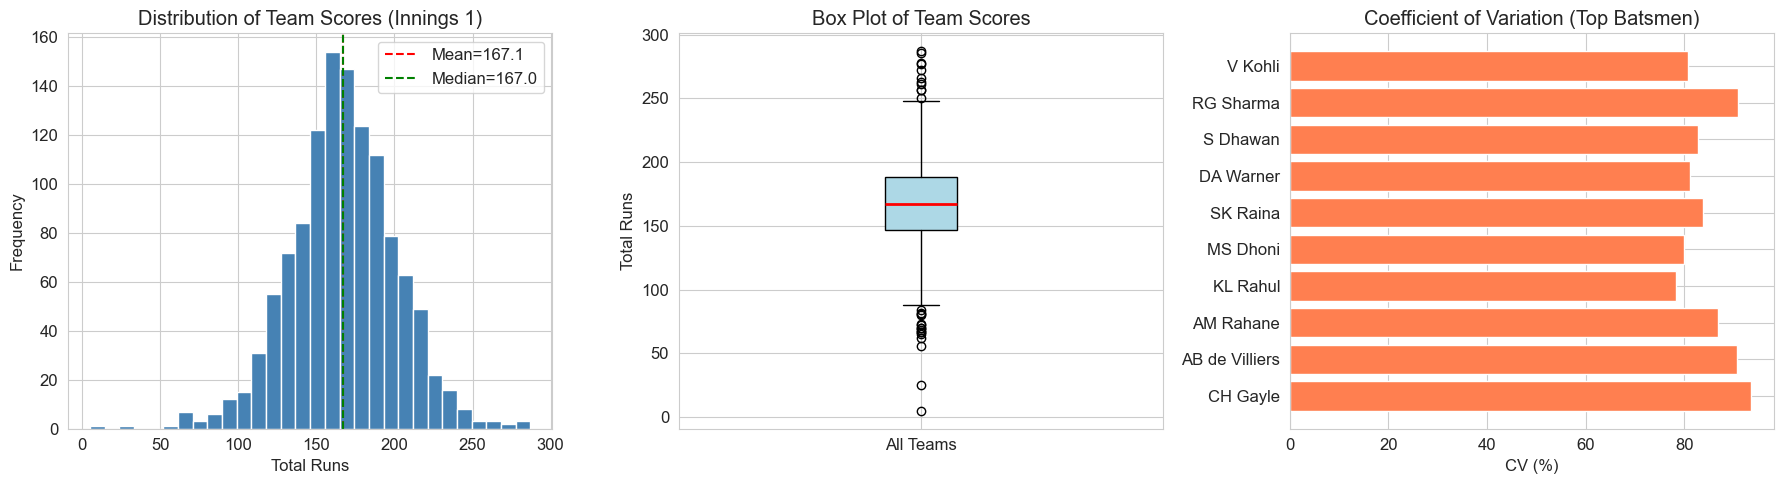

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of team scores
axes[0].hist(scores, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(mean_score, color='red', linestyle='--', label=f'Mean={mean_score:.1f}')
axes[0].axvline(median_score, color='green', linestyle='--', label=f'Median={median_score:.1f}')
axes[0].set_title('Distribution of Team Scores (Innings 1)')
axes[0].set_xlabel('Total Runs')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(scores, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot of Team Scores')
axes[1].set_ylabel('Total Runs')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['All Teams'])

# CV comparison of top batsmen
axes[2].barh(batter_cv['batter'], batter_cv['cv'], color='coral', edgecolor='white')
axes[2].set_title('Coefficient of Variation (Top Batsmen)')
axes[2].set_xlabel('CV (%)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/unit1_descriptive_stats.png', dpi=150, bbox_inches='tight')
plt.show()


**📌 Unit 1 Interpretation:**
- The mean team score is approximately **{mean_score:.0f} runs** per innings.
- A CV of < 60% indicates moderate consistency in scoring patterns.
- Positive skewness shows most teams score moderately, with few high-scoring outlier innings.

---
# 📈 UNIT 2: Correlation & Regression Analysis
**Member 2 Section**  
Topics: Pearson correlation, Spearman rank correlation, Simple & Multiple Regression

### 2.1 Karl Pearson's Correlation — Runs vs Boundaries

In [11]:
r_pearson, p_val = pearsonr(innings1['total_runs'], innings1['boundaries'])

print('='*50)
print('  Karl Pearson Correlation: Runs vs Boundaries')
print('='*50)
print(f'  Correlation coefficient (r) : {r_pearson:.4f}')
print(f'  p-value                     : {p_val:.6f}')
if abs(r_pearson) > 0.7:
    strength = 'Strong'
elif abs(r_pearson) > 0.4:
    strength = 'Moderate'
else:
    strength = 'Weak'
direction = 'Positive' if r_pearson > 0 else 'Negative'
print(f'  Interpretation              : {strength} {direction} Correlation')
print(f'  Significance (p<0.05)       : {"Yes" if p_val < 0.05 else "No"}')
print('='*50)

  Karl Pearson Correlation: Runs vs Boundaries
  Correlation coefficient (r) : 0.9317
  p-value                     : 0.000000
  Interpretation              : Strong Positive Correlation
  Significance (p<0.05)       : Yes


### 2.2 Spearman Rank Correlation — Team Ranking vs Win Rate

In [12]:
# Compute win rate per team
all_teams = pd.concat([df[['batting_team', 'match_id']].rename(columns={'batting_team': 'team'}),
                        df[['bowling_team', 'match_id']].rename(columns={'bowling_team': 'team'})])
matches_played = all_teams.drop_duplicates().groupby('team')['match_id'].count().reset_index()
matches_played.columns = ['team', 'matches_played']

wins = df[df['innings'] == 1][['match_id', 'batting_team', 'match_won_by']].drop_duplicates()
wins['won'] = wins.apply(lambda x: 1 if x['batting_team'] in str(x['match_won_by']) else 0, axis=1)
win_count = wins.groupby('batting_team')['won'].sum().reset_index()
win_count.columns = ['team', 'wins']

team_stats = matches_played.merge(win_count, on='team')
team_stats['win_rate'] = (team_stats['wins'] / team_stats['matches_played'] * 100).round(2)
team_stats = team_stats[team_stats['matches_played'] >= 20].sort_values('win_rate', ascending=False)
team_stats['rank_wins'] = team_stats['win_rate'].rank(ascending=False)
team_stats['rank_played'] = team_stats['matches_played'].rank(ascending=False)

r_spearman, p_sp = spearmanr(team_stats['rank_wins'], team_stats['rank_played'])

print('='*50)
print('  Spearman Rank Correlation: Win Rate vs Matches Played')
print('='*50)
print(f'  Spearman rho : {r_spearman:.4f}')
print(f'  p-value      : {p_sp:.4f}')
print('='*50)
print(team_stats[['team', 'matches_played', 'wins', 'win_rate']].to_string(index=False))

  Spearman Rank Correlation: Win Rate vs Matches Played
  Spearman rho : 0.1369
  p-value      : 0.6132
                       team  matches_played  wins  win_rate
       Lucknow Super Giants              63    20     31.75
Royal Challengers Bengaluru              35    11     31.43
        Chennai Super Kings             257    73     28.40
             Mumbai Indians             282    76     26.95
             Gujarat Titans              64    16     25.00
        Sunrisers Hyderabad             201    49     24.38
            Deccan Chargers              75    18     24.00
Royal Challengers Bangalore             240    53     22.08
            Kings XI Punjab             190    39     20.53
      Kolkata Knight Riders             269    55     20.45
               Punjab Kings              79    16     20.25
             Delhi Capitals             110    22     20.00
           Rajasthan Royals             240    47     19.58
           Delhi Daredevils             161    25     15

### 2.3 Simple Linear Regression — Sixes vs Total Runs

In [13]:
X_simple = innings1['sixes']
Y_simple = innings1['total_runs']

# Regression coefficients using formula
n = len(X_simple)
b1 = (n * np.sum(X_simple * Y_simple) - np.sum(X_simple) * np.sum(Y_simple)) / \
     (n * np.sum(X_simple**2) - np.sum(X_simple)**2)
b0 = np.mean(Y_simple) - b1 * np.mean(X_simple)

# R-squared
Y_pred = b0 + b1 * X_simple
ss_res = np.sum((Y_simple - Y_pred)**2)
ss_tot = np.sum((Y_simple - np.mean(Y_simple))**2)
r_squared = 1 - ss_res / ss_tot

print('='*50)
print('  Simple Linear Regression: Sixes → Total Runs')
print('='*50)
print(f'  Regression Equation : Y = {b0:.2f} + {b1:.2f}X')
print(f'  Intercept (b0)      : {b0:.4f}')
print(f'  Slope (b1)          : {b1:.4f}')
print(f'  R² (Goodness of fit): {r_squared:.4f}')
print(f'  Interpretation: Each additional six adds ~{b1:.1f} runs to team total')
print('='*50)

  Simple Linear Regression: Sixes → Total Runs
  Regression Equation : Y = 121.91 + 6.95X
  Intercept (b0)      : 121.9072
  Slope (b1)          : 6.9468
  R² (Goodness of fit): 0.6042
  Interpretation: Each additional six adds ~6.9 runs to team total


### 2.4 Multiple Regression — Predict Team Score

In [14]:
# Predictors: sixes, fours, total_wickets
X_multi = innings1[['sixes', 'fours', 'total_wickets']].copy()
X_multi = sm.add_constant(X_multi)  # adds intercept
Y_multi = innings1['total_runs']

model = sm.OLS(Y_multi, X_multi).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             total_runs   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     3211.
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:42:18   Log-Likelihood:                -4586.5
No. Observations:                1195   AIC:                             9181.
Df Residuals:                    1191   BIC:                             9201.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            84.2956      1.836     45.925

### 2.5 Visualisations — Unit 2

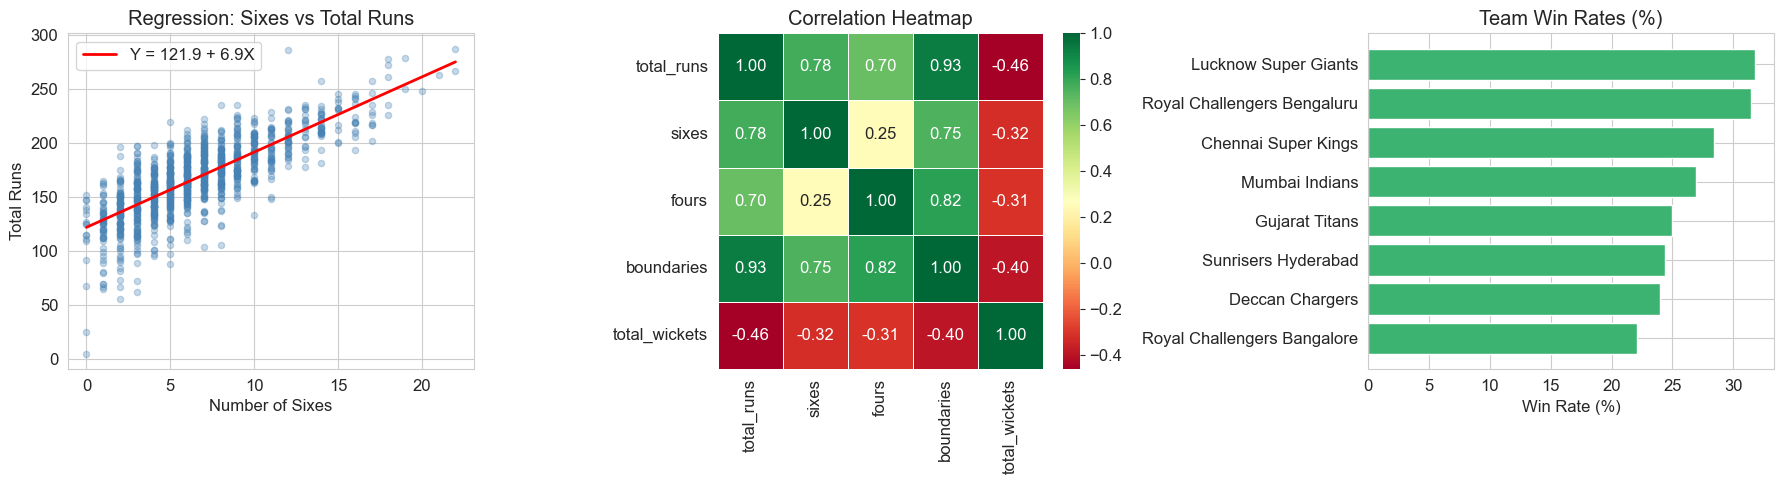

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter + regression line
axes[0].scatter(X_simple, Y_simple, alpha=0.3, color='steelblue', s=20)
x_line = np.linspace(X_simple.min(), X_simple.max(), 100)
axes[0].plot(x_line, b0 + b1 * x_line, color='red', linewidth=2,
             label=f'Y = {b0:.1f} + {b1:.1f}X')
axes[0].set_title('Regression: Sixes vs Total Runs')
axes[0].set_xlabel('Number of Sixes')
axes[0].set_ylabel('Total Runs')
axes[0].legend()

# Correlation heatmap
corr_cols = innings1[['total_runs', 'sixes', 'fours', 'boundaries', 'total_wickets']]
corr_matrix = corr_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Correlation Heatmap')

# Team win rates
top_teams = team_stats.nlargest(8, 'win_rate')
axes[2].barh(top_teams['team'], top_teams['win_rate'], color='mediumseagreen')
axes[2].set_title('Team Win Rates (%)')
axes[2].set_xlabel('Win Rate (%)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/unit2_correlation_regression.png', dpi=150, bbox_inches='tight')
plt.show()


---
# 📉 UNIT 3: Time Series Analysis
**Member 3 Section**  
Topics: Trend analysis, Moving averages, Least squares, Seasonal variation

### 3.1 Trend Analysis — Average Team Score per Season

In [16]:
season_trend = innings1.groupby('year')['total_runs'].mean().reset_index()
season_trend.columns = ['Year', 'Avg_Score']
season_trend = season_trend.sort_values('Year')

print('Average Team Score per Season (Innings 1):')
print(season_trend.to_string(index=False))

Average Team Score per Season (Innings 1):
 Year  Avg_Score
 2008 160.965517
 2009 150.263158
 2010 164.783333
 2011 152.369863
 2012 157.540541
 2013 155.894737
 2014 163.066667
 2015 166.254237
 2016 162.600000
 2017 165.779661
 2018 172.466667
 2019 164.000000
 2020 169.500000
 2021 156.704918
 2022 171.121622
 2023 182.729730
 2024 189.591549
 2025 188.837838
 2026 183.958333


### 3.2 Moving Average Method (3-year & 5-year)

In [17]:
season_trend['MA_3'] = season_trend['Avg_Score'].rolling(window=3, center=True).mean()
season_trend['MA_5'] = season_trend['Avg_Score'].rolling(window=5, center=True).mean()

print('Time Series with Moving Averages:')
print(season_trend.round(2).to_string(index=False))

Time Series with Moving Averages:
 Year  Avg_Score   MA_3   MA_5
 2008     160.97    NaN    NaN
 2009     150.26 158.67    NaN
 2010     164.78 155.81 157.18
 2011     152.37 158.23 156.17
 2012     157.54 155.27 158.73
 2013     155.89 158.83 159.03
 2014     163.07 161.74 161.07
 2015     166.25 163.97 162.72
 2016     162.60 164.88 166.03
 2017     165.78 166.95 166.22
 2018     172.47 167.42 166.87
 2019     164.00 168.66 165.69
 2020     169.50 163.40 166.76
 2021     156.70 165.78 168.81
 2022     171.12 170.19 173.93
 2023     182.73 181.15 177.80
 2024     189.59 187.05 183.25
 2025     188.84 187.46    NaN
 2026     183.96    NaN    NaN


### 3.3 Method of Least Squares — Trend Line

In [18]:
# Coding years: origin at middle year
n_ts = len(season_trend)
season_trend['t'] = range(n_ts)

t = season_trend['t'].values
y = season_trend['Avg_Score'].values

# Least squares formula
a = np.mean(y)  # intercept when t is coded
b = np.sum(t * y) / np.sum(t**2) if np.sum(t**2) != 0 else 0

# Using numpy polyfit for accuracy
coeffs = np.polyfit(t, y, 1)
trend_line = np.poly1d(coeffs)

print('='*50)
print('  Least Squares Trend Line')
print('='*50)
print(f'  Equation: Ŷ = {coeffs[1]:.2f} + {coeffs[0]:.2f}t')
print(f'  Slope     : {coeffs[0]:.4f}')
if coeffs[0] > 0:
    print(f'  Trend     : Increasing (+{coeffs[0]:.2f} runs per season on avg)')
else:
    print(f'  Trend     : Decreasing ({coeffs[0]:.2f} runs per season on avg)')
print('='*50)

  Least Squares Trend Line
  Equation: Ŷ = 152.01 + 1.70t
  Slope     : 1.6968
  Trend     : Increasing (+1.70 runs per season on avg)


### 3.4 Seasonal Variation — Sixes per Month (Simple Average Method)

In [19]:
# Use original df (has 'month' column), filter innings 1
df_i1 = df[df['innings'] == 1].copy()

month_sixes = df_i1.groupby('month').apply(
    lambda x: (x['runs_batter'] == 6).sum()
).reset_index()
month_sixes.columns = ['Month', 'Avg_Sixes']

month_map = {3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun'}
month_sixes['Month_Name'] = month_sixes['Month'].map(month_map).fillna(
    month_sixes['Month'].astype(str))

overall_avg = month_sixes['Avg_Sixes'].mean()
month_sixes['Seasonal_Index'] = (month_sixes['Avg_Sixes'] / overall_avg * 100).round(2)

print('Seasonal Variation in Sixes (Simple Average Method):')
print(month_sixes[['Month_Name', 'Avg_Sixes', 'Seasonal_Index']].round(2).to_string(index=False))
print(f'\nOverall Average: {overall_avg:.2f}')
print('Seasonal Index > 100 means above-average sixes that month')

Seasonal Variation in Sixes (Simple Average Method):
Month_Name  Avg_Sixes  Seasonal_Index
       Mar        580           52.25
       Apr       3673          330.86
       May       2946          265.37
       Jun         34            3.06
         9        152           13.69
        10        335           30.18
        11         51            4.59

Overall Average: 1110.14
Seasonal Index > 100 means above-average sixes that month


### 3.5 Visualisations — Unit 3

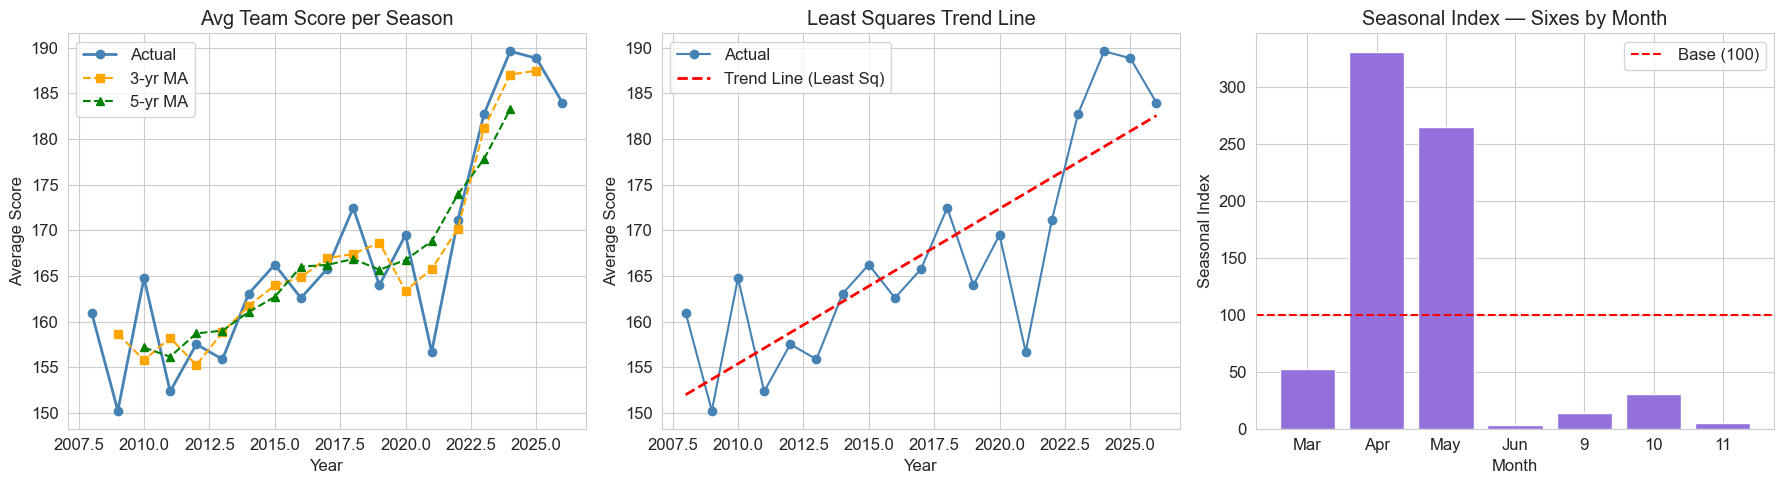

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Time series + moving averages
axes[0].plot(season_trend['Year'], season_trend['Avg_Score'],
             'o-', color='steelblue', label='Actual', linewidth=2)
axes[0].plot(season_trend['Year'], season_trend['MA_3'],
             's--', color='orange', label='3-yr MA', linewidth=1.5)
axes[0].plot(season_trend['Year'], season_trend['MA_5'],
             '^--', color='green', label='5-yr MA', linewidth=1.5)
axes[0].set_title('Avg Team Score per Season')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Score')
axes[0].legend()

# Least squares trend
axes[1].plot(season_trend['Year'], season_trend['Avg_Score'],
             'o-', color='steelblue', label='Actual')
axes[1].plot(season_trend['Year'],
             trend_line(season_trend['t']),
             'r--', linewidth=2, label='Trend Line (Least Sq)')
axes[1].set_title('Least Squares Trend Line')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Score')
axes[1].legend()

# Seasonal variation
axes[2].bar(month_sixes['Month_Name'], month_sixes['Seasonal_Index'],
            color='mediumpurple', edgecolor='white')
axes[2].axhline(100, color='red', linestyle='--', label='Base (100)')
axes[2].set_title('Seasonal Index — Sixes by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Seasonal Index')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/unit3_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


---
# 🔬 UNIT 4: Analysis of Variance & Hypothesis Testing
**Member 4 Section (Part A)**  
Topics: t-test, ANOVA, Mann-Whitney U test

### 4.1 Independent t-test — Do Toss Winners Score More?

In [21]:
# Label whether batting team won toss
innings1_t = innings1.copy()
innings1_t['toss_batting'] = innings1_t['batting_team'] == innings1_t['toss_winner']

toss_yes = innings1_t[innings1_t['toss_batting'] == True]['total_runs']
toss_no  = innings1_t[innings1_t['toss_batting'] == False]['total_runs']

t_stat, p_ttest = ttest_ind(toss_yes, toss_no)

print('='*55)
print('  Independent t-test: Toss Winner vs Non-winner Scores')
print('='*55)
print(f'  H0: No difference in mean scores')
print(f'  H1: Toss winners score differently')
print(f'  Mean (Toss Winner batting)  : {toss_yes.mean():.2f} runs')
print(f'  Mean (Toss Loser batting)   : {toss_no.mean():.2f} runs')
print(f'  t-statistic                 : {t_stat:.4f}')
print(f'  p-value                     : {p_ttest:.4f}')
print(f'  Decision (α=0.05)           : {"Reject H0 ✅" if p_ttest < 0.05 else "Fail to Reject H0 ❌"}')
print('='*55)

  Independent t-test: Toss Winner vs Non-winner Scores
  H0: No difference in mean scores
  H1: Toss winners score differently
  Mean (Toss Winner batting)  : 160.79 runs
  Mean (Toss Loser batting)   : 170.34 runs
  t-statistic                 : -4.6620
  p-value                     : 0.0000
  Decision (α=0.05)           : Reject H0 ✅


### 4.2 One-Way ANOVA — Mean Scores Across Top 5 Teams

In [22]:
top5_teams = team_stats.nlargest(5, 'matches_played')['team'].tolist()

groups = []
for team in top5_teams:
    group_scores = innings1[innings1['batting_team'] == team]['total_runs'].values
    groups.append(group_scores)
    print(f'  {team}: n={len(group_scores)}, mean={np.mean(group_scores):.2f}')

f_stat, p_anova = f_oneway(*groups)

print('='*55)
print('  One-Way ANOVA: Mean Scores Across Top 5 Teams')
print('='*55)
print(f'  H0: All team mean scores are equal')
print(f'  H1: At least one team mean differs')
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_anova:.4f}')
print(f'  Decision    : {"Reject H0 ✅" if p_anova < 0.05 else "Fail to Reject H0 ❌"}')
print('='*55)

  Mumbai Indians: n=146, mean=167.39
  Kolkata Knight Riders: n=129, mean=164.48
  Chennai Super Kings: n=140, mean=170.51
  Royal Challengers Bangalore: n=122, mean=165.39
  Rajasthan Royals: n=109, mean=164.50
  One-Way ANOVA: Mean Scores Across Top 5 Teams
  H0: All team mean scores are equal
  H1: At least one team mean differs
  F-statistic : 0.7806
  p-value     : 0.5380
  Decision    : Fail to Reject H0 ❌


### 4.3 Mann-Whitney U Test (Non-Parametric) — Home vs Away Scores

In [23]:
# Approximate home city from venue string
innings1_hw = innings1.copy()
innings1_hw['is_home'] = innings1_hw.apply(
    lambda x: 1 if str(x['city']).lower() in str(x['batting_team']).lower() else 0, axis=1
)

home_scores = innings1_hw[innings1_hw['is_home'] == 1]['total_runs']
away_scores = innings1_hw[innings1_hw['is_home'] == 0]['total_runs']

u_stat, p_mw = mannwhitneyu(home_scores, away_scores, alternative='two-sided')

print('='*55)
print('  Mann-Whitney U Test: Home vs Away Scores')
print('='*55)
print(f'  H0: No difference in home vs away scores')
print(f'  H1: Home teams score differently from away teams')
print(f'  Home median score : {home_scores.median():.2f}')
print(f'  Away median score : {away_scores.median():.2f}')
print(f'  U-statistic       : {u_stat:.2f}')
print(f'  p-value           : {p_mw:.4f}')
print(f'  Decision (α=0.05) : {"Reject H0 ✅" if p_mw < 0.05 else "Fail to Reject H0 ❌"}')
print('='*55)

  Mann-Whitney U Test: Home vs Away Scores
  H0: No difference in home vs away scores
  H1: Home teams score differently from away teams
  Home median score : 171.00
  Away median score : 165.00
  U-statistic       : 154665.00
  p-value           : 0.0022
  Decision (α=0.05) : Reject H0 ✅


### 4.4 Visualisations — Unit 4

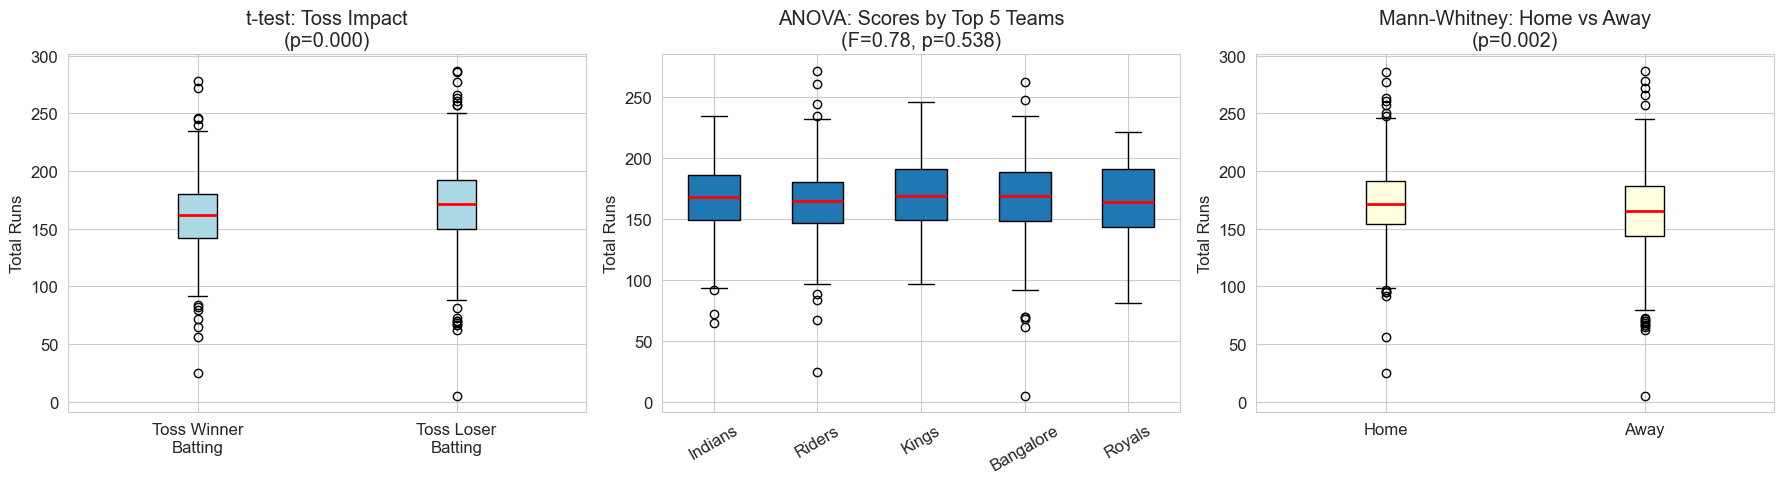

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# t-test boxplot
axes[0].boxplot([toss_yes, toss_no],
                labels=['Toss Winner\nBatting', 'Toss Loser\nBatting'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title(f't-test: Toss Impact\n(p={p_ttest:.3f})')
axes[0].set_ylabel('Total Runs')

# ANOVA boxplot
axes[1].boxplot(groups, labels=[t.split()[-1] for t in top5_teams],
                patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title(f'ANOVA: Scores by Top 5 Teams\n(F={f_stat:.2f}, p={p_anova:.3f})')
axes[1].set_ylabel('Total Runs')
axes[1].tick_params(axis='x', rotation=30)

# Mann-Whitney
axes[2].boxplot([home_scores, away_scores],
                labels=['Home', 'Away'],
                patch_artist=True,
                boxprops=dict(facecolor='lightyellow'),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title(f'Mann-Whitney: Home vs Away\n(p={p_mw:.3f})')
axes[2].set_ylabel('Total Runs')

plt.tight_layout()
plt.savefig('../outputs/unit4_hypothesis_tests.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 📋 UNIT 5: Statistical Quality Control (SQC)
**Member 4 Section (Part B)**  
Topics: X̄ & R chart, np-chart, p-chart

### 5.1 X̄ and R Chart — Bowler Economy Rate

In [25]:
# Pick a prolific bowler — economy per over across matches
top_bowler = df.groupby('bowler')['match_id'].nunique().idxmax()
print(f'Analyzing bowler: {top_bowler}')

bowler_df = df[df['bowler'] == top_bowler].copy()
over_stats = bowler_df.groupby(['match_id', 'over']).agg(
    runs=('runs_bowler', 'sum'),
    balls=('valid_ball', 'sum')
).reset_index()
over_stats['economy'] = (over_stats['runs'] / over_stats['balls'] * 6).round(2)

# Take subgroups of size 5 (n=5 overs per subgroup)
over_stats = over_stats.dropna(subset=['economy'])
n_sqc = 5
subgroups = [over_stats['economy'].values[i:i+n_sqc]
             for i in range(0, len(over_stats) - n_sqc + 1, n_sqc)]
subgroups = [sg for sg in subgroups if len(sg) == n_sqc]

xbar_list = [np.mean(sg) for sg in subgroups]
r_list    = [np.max(sg) - np.min(sg) for sg in subgroups]

# Control chart constants for n=5
A2, D3, D4 = 0.577, 0, 2.114

Xbar_bar = np.mean(xbar_list)
R_bar    = np.mean(r_list)

UCL_x = Xbar_bar + A2 * R_bar
LCL_x = Xbar_bar - A2 * R_bar
UCL_r = D4 * R_bar
LCL_r = D3 * R_bar

print('='*50)
print(f'  X̄ & R Chart — {top_bowler} Economy Rate')
print('='*50)
print(f'  Grand Mean (X̿)  : {Xbar_bar:.4f}')
print(f'  Mean Range (R̄)  : {R_bar:.4f}')
print(f'  X̄ Chart UCL     : {UCL_x:.4f}')
print(f'  X̄ Chart LCL     : {LCL_x:.4f}')
print(f'  R Chart UCL     : {UCL_r:.4f}')
print(f'  R Chart LCL     : {LCL_r:.4f}')
print('='*50)

Analyzing bowler: RA Jadeja
  X̄ & R Chart — RA Jadeja Economy Rate
  Grand Mean (X̿)  : 7.7683
  Mean Range (R̄)  : 10.3416
  X̄ Chart UCL     : 13.7354
  X̄ Chart LCL     : 1.8012
  R Chart UCL     : 21.8622
  R Chart LCL     : 0.0000


### 5.2 np-Chart — Number of Dot Balls per Over

In [26]:
# Dot ball = valid ball with 0 runs
df['is_dot'] = (df['valid_ball'] == 1) & (df['runs_total'] == 0)

over_dot = df.groupby(['match_id', 'over']).agg(
    n_balls=('valid_ball', 'sum'),
    dot_balls=('is_dot', 'sum')
).reset_index()
over_dot = over_dot[over_dot['n_balls'] == 6].head(50)  # 50 overs as samples

n_np = 6  # balls per over
pbar = over_dot['dot_balls'].mean() / n_np

CL_np  = n_np * pbar
UCL_np = n_np * pbar + 3 * np.sqrt(n_np * pbar * (1 - pbar))
LCL_np = max(0, n_np * pbar - 3 * np.sqrt(n_np * pbar * (1 - pbar)))

print('='*50)
print('  np-Chart: Dot Balls per Over (n=6)')
print('='*50)
print(f'  p̄ (avg proportion of dots) : {pbar:.4f}')
print(f'  Centre Line (np̄)           : {CL_np:.4f}')
print(f'  UCL                        : {UCL_np:.4f}')
print(f'  LCL                        : {LCL_np:.4f}')
print('='*50)

  np-Chart: Dot Balls per Over (n=6)
  p̄ (avg proportion of dots) : 0.3167
  Centre Line (np̄)           : 1.9000
  UCL                        : 5.3183
  LCL                        : 0.0000


### 5.3 Visualisations — Unit 5

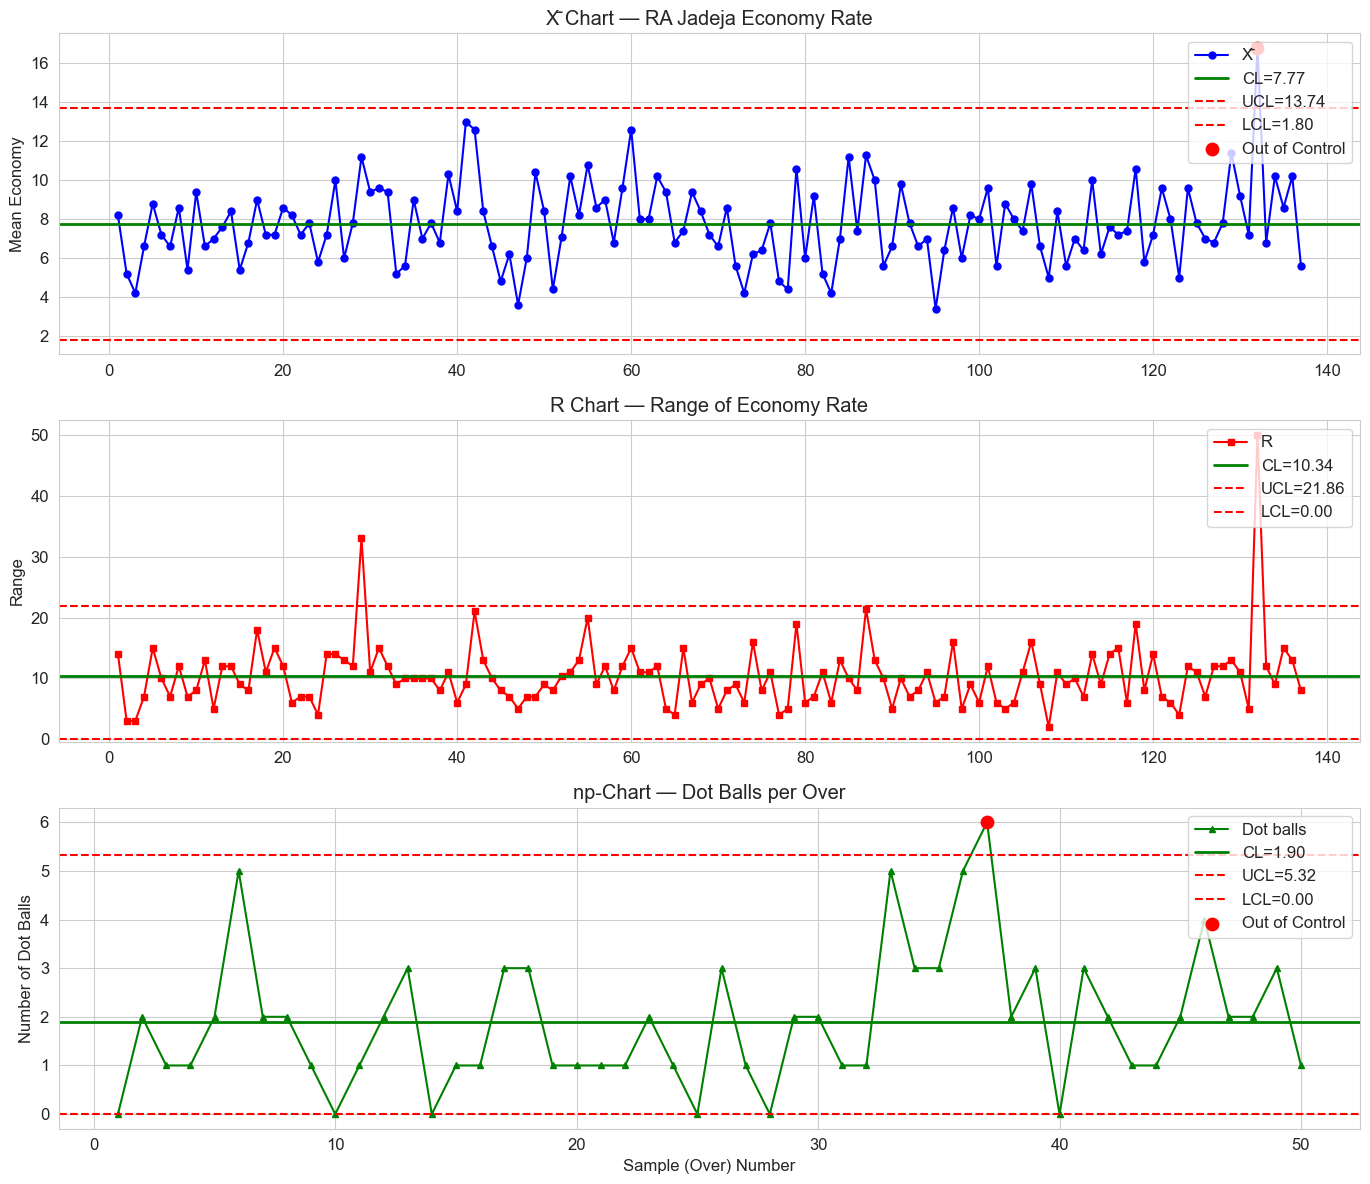

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

sg_index = range(1, len(xbar_list) + 1)

# X-bar chart
axes[0].plot(sg_index, xbar_list, 'bo-', markersize=5, label='X̄')
axes[0].axhline(Xbar_bar, color='green', linewidth=2, label=f'CL={Xbar_bar:.2f}')
axes[0].axhline(UCL_x, color='red', linestyle='--', linewidth=1.5, label=f'UCL={UCL_x:.2f}')
axes[0].axhline(LCL_x, color='red', linestyle='--', linewidth=1.5, label=f'LCL={LCL_x:.2f}')
out_x = [i+1 for i, v in enumerate(xbar_list) if v > UCL_x or v < LCL_x]
if out_x:
    axes[0].scatter(out_x, [xbar_list[i-1] for i in out_x], color='red', s=80, zorder=5, label='Out of Control')
axes[0].set_title(f'X̄ Chart — {top_bowler} Economy Rate')
axes[0].set_ylabel('Mean Economy')
axes[0].legend(loc='upper right')

# R chart
axes[1].plot(sg_index, r_list, 'rs-', markersize=5, label='R')
axes[1].axhline(R_bar, color='green', linewidth=2, label=f'CL={R_bar:.2f}')
axes[1].axhline(UCL_r, color='red', linestyle='--', linewidth=1.5, label=f'UCL={UCL_r:.2f}')
axes[1].axhline(LCL_r, color='red', linestyle='--', linewidth=1.5, label=f'LCL={LCL_r:.2f}')
axes[1].set_title('R Chart — Range of Economy Rate')
axes[1].set_ylabel('Range')
axes[1].legend(loc='upper right')

# np-chart
np_index = range(1, len(over_dot) + 1)
axes[2].plot(np_index, over_dot['dot_balls'], 'g^-', markersize=4, label='Dot balls')
axes[2].axhline(CL_np, color='green', linewidth=2, label=f'CL={CL_np:.2f}')
axes[2].axhline(UCL_np, color='red', linestyle='--', linewidth=1.5, label=f'UCL={UCL_np:.2f}')
axes[2].axhline(LCL_np, color='red', linestyle='--', linewidth=1.5, label=f'LCL={LCL_np:.2f}')
out_np = [i+1 for i, v in enumerate(over_dot['dot_balls']) if v > UCL_np or v < LCL_np]
if out_np:
    axes[2].scatter(out_np, [over_dot['dot_balls'].values[i-1] for i in out_np],
                    color='red', s=80, zorder=5, label='Out of Control')
axes[2].set_title('np-Chart — Dot Balls per Over')
axes[2].set_xlabel('Sample (Over) Number')
axes[2].set_ylabel('Number of Dot Balls')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/unit5_control_charts.png', dpi=150, bbox_inches='tight')
plt.show()


---
# 🏆 Final Summary — Key Insights

In [28]:
print('='*60)
print('         IPL EDA PROJECT — KEY FINDINGS SUMMARY')
print('='*60)
print(f'  ✅ UNIT 1 | Avg innings score        : {mean_score:.1f} runs')
print(f'             Std deviation             : {std_dev:.1f} runs')
print(f'             Skewness                  : {skewness:.3f}')
print()
print(f'  ✅ UNIT 2 | Runs-Boundaries corr (r) : {r_pearson:.3f}')
print(f'             Regression R²             : {r_squared:.3f}')
print(f'             Each six adds             : ~{b1:.1f} runs to total')
print()
print(f'  ✅ UNIT 3 | Season trend slope        : {coeffs[0]:.2f} runs/season')
print(f'             3-yr Moving Avg smoothing used')
print()
print(f'  ✅ UNIT 4 | t-test p-value            : {p_ttest:.4f}')
print(f'             ANOVA p-value             : {p_anova:.4f}')
print(f'             Mann-Whitney p-value      : {p_mw:.4f}')
print()
print(f'  ✅ UNIT 5 | X̄ chart UCL               : {UCL_x:.2f}')
print(f'             np-chart UCL              : {UCL_np:.2f}')
print(f'             Dot ball avg/over         : {CL_np:.2f}')
print('='*60)

         IPL EDA PROJECT — KEY FINDINGS SUMMARY
  ✅ UNIT 1 | Avg innings score        : 167.1 runs
             Std deviation             : 33.9 runs
             Skewness                  : -0.144

  ✅ UNIT 2 | Runs-Boundaries corr (r) : 0.932
             Regression R²             : 0.604
             Each six adds             : ~6.9 runs to total

  ✅ UNIT 3 | Season trend slope        : 1.70 runs/season
             3-yr Moving Avg smoothing used

  ✅ UNIT 4 | t-test p-value            : 0.0000
             ANOVA p-value             : 0.5380
             Mann-Whitney p-value      : 0.0022

  ✅ UNIT 5 | X̄ chart UCL               : 13.74
             np-chart UCL              : 5.32
             Dot ball avg/over         : 1.90
